In [1]:
# Installing required libraries for Task 2
import sys
!{sys.executable} -m pip install scikit-learn

# Task 2: Customer Segmentation Using Unsupervised Learning

**Organization:** DevelopersHub Corporation  
**Internship:** Data Science & Analytics — Advanced Tasks  
**Author:** Khola Asghar  
**Date:** 25 May 2026  
**Dataset:** Mall Customers Dataset (Kaggle)

---

## 1. Introduction and Problem Statement

Understanding customer behavior is crucial for any business.
By grouping customers into segments based on their spending habits
and income, businesses can create targeted marketing strategies
for each group.

The goal of this task is to apply K-Means Clustering to segment
mall customers based on their annual income and spending score,
and then suggest relevant marketing strategies for each segment.

Business Question: Which distinct customer groups exist in our
mall and what marketing strategy should we apply to each group?

## 2. Dataset Understanding and Description

The Mall Customers Dataset contains information about 200 mall
customers including their customer ID, gender, age, annual income
in thousands of dollars, and spending score from 1 to 100.

The spending score is assigned by the mall based on customer
behavior and purchasing data. Higher scores mean higher spending.

This is an unsupervised learning problem because we do not have
a predefined target variable. We let the algorithm find natural
groupings in the data.

In [2]:
# ================================================
# Task 2: Customer Segmentation Using K-Means
# DevelopersHub Corporation - Advanced Internship
# ================================================

# Importing all required libraries
import pandas as pd                          # Data loading and manipulation
import numpy as np                           # Numerical operations
import matplotlib.pyplot as plt              # Basic visualizations
import seaborn as sns                        # Advanced visualizations
import warnings
warnings.filterwarnings('ignore')            # Hide unnecessary warnings

# Machine Learning libraries
from sklearn.cluster import KMeans           # K-Means Clustering
from sklearn.preprocessing import StandardScaler  # Feature scaling
from sklearn.decomposition import PCA        # Dimensionality reduction

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Data Cleaning and Preparation

In this section we load the dataset, inspect its structure,
check for missing values, and prepare the data for clustering.

In [3]:
# ================================================
# Loading the Dataset
# ================================================

df = pd.read_csv(r'C:\Users\dell\Downloads\archive (4)\Mall_Customers.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (200, 5)

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
# ================================================
# Dataset Inspection
# Understanding data types and missing values
# ================================================

# Display data types
print("Data Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Gender distribution
print("\nGender Distribution:")
print(df['Genre'].value_counts())

Data Types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0

Basic Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max

In [5]:
# ================================================
# Preparing Data for Clustering
# We use Annual Income and Spending Score
# as our main clustering features
# ================================================

# Rename columns for easier use
df.columns = ['CustomerID', 'Gender', 'Age',
              'AnnualIncome', 'SpendingScore']

# Select features for clustering
X = df[['AnnualIncome', 'SpendingScore']].copy()

# Scale the features for better clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
print("1. Annual Income (k$)")
print("2. Spending Score (1-100)")
print("\nData scaled successfully!")
print("Scaled data shape:", X_scaled.shape)

Features selected for clustering:
1. Annual Income (k$)
2. Spending Score (1-100)

Data scaled successfully!
Scaled data shape: (200, 2)


## 4. Exploratory Data Analysis (EDA)

We create visualizations to understand the distribution of
customer data before applying clustering. This helps us
understand the patterns that exist in the dataset.

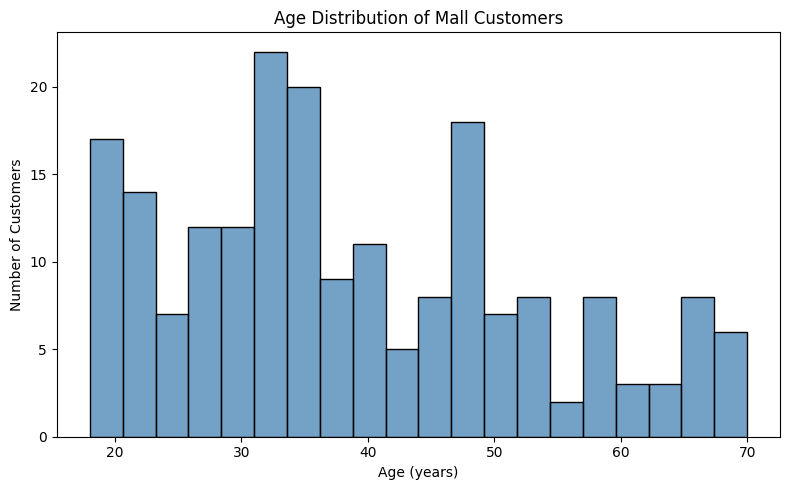

Most customers are between 25 and 45 years old


In [6]:
# ================================================
# Visualization 1: Age Distribution
# Understanding the age spread of customers
# ================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Age',                        # Age values
    bins=20,                        # Number of bins
    color='steelblue',              # Bar color
    edgecolor='black'               # Bar border
)

plt.title('Age Distribution of Mall Customers')
plt.xlabel('Age (years)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

print("Most customers are between 25 and 45 years old")

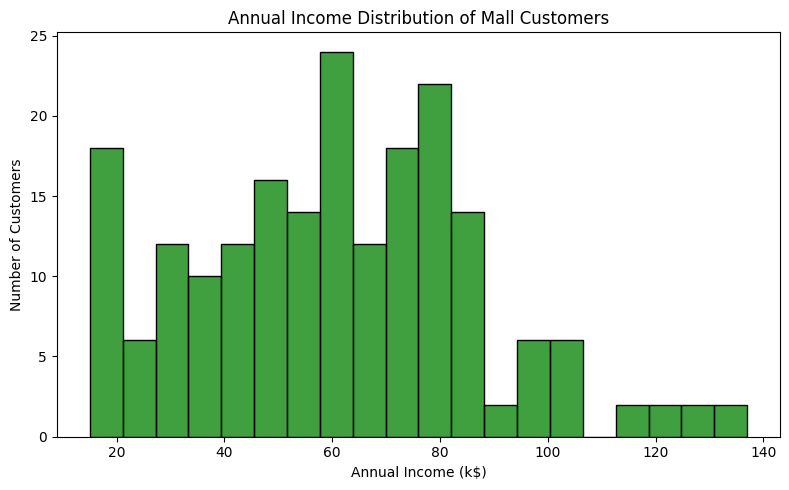

Income is fairly evenly distributed across customers


In [7]:
# ================================================
# Visualization 2: Annual Income Distribution
# Understanding income spread of customers
# ================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='AnnualIncome',               # Income values
    bins=20,                        # Number of bins
    color='green',                  # Bar color
    edgecolor='black'               # Bar border
)

plt.title('Annual Income Distribution of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('income_distribution.png')
plt.show()

print("Income is fairly evenly distributed across customers")

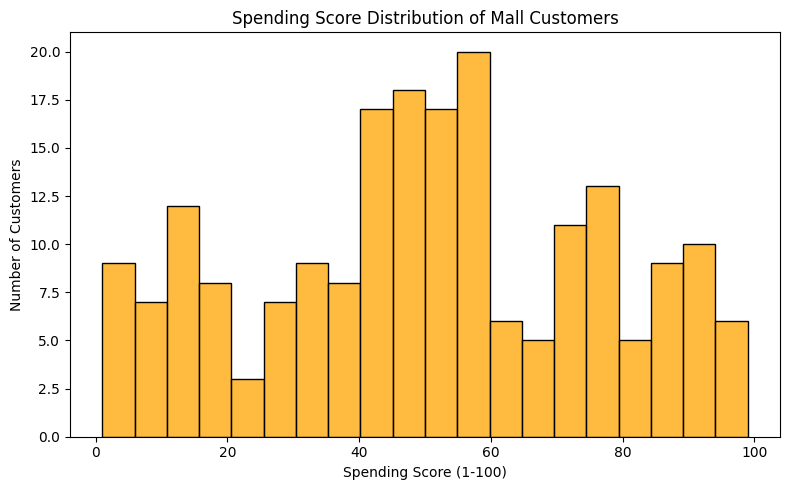

Spending scores are spread across all ranges


In [8]:
# ================================================
# Visualization 3: Spending Score Distribution
# Understanding spending behavior of customers
# ================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='SpendingScore',              # Spending score values
    bins=20,                        # Number of bins
    color='orange',                 # Bar color
    edgecolor='black'               # Bar border
)

plt.title('Spending Score Distribution of Mall Customers')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('spending_distribution.png')
plt.show()

print("Spending scores are spread across all ranges")

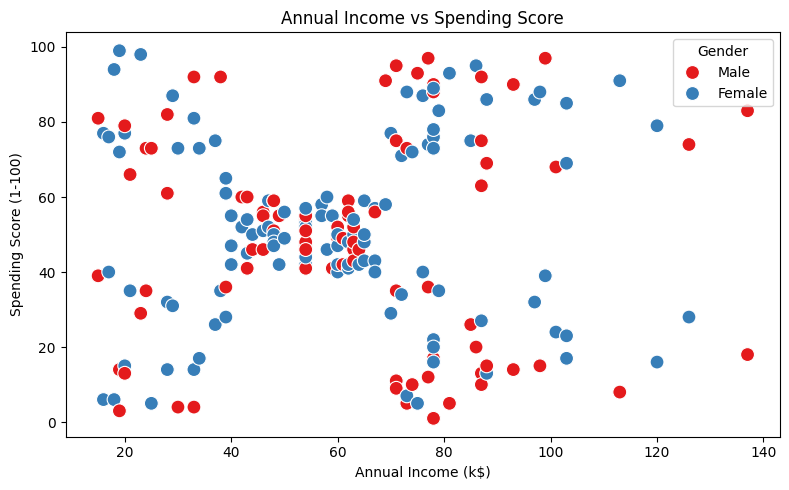

We can already see natural groupings forming in the data!


In [9]:
# ================================================
# Visualization 4: Income vs Spending Score
# Looking for natural groupings before clustering
# ================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='AnnualIncome',               # X axis: income
    y='SpendingScore',              # Y axis: spending
    hue='Gender',                   # Color by gender
    palette='Set1',                 # Color palette
    s=100                           # Point size
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.savefig('income_vs_spending.png')
plt.show()

print("We can already see natural groupings forming in the data!")

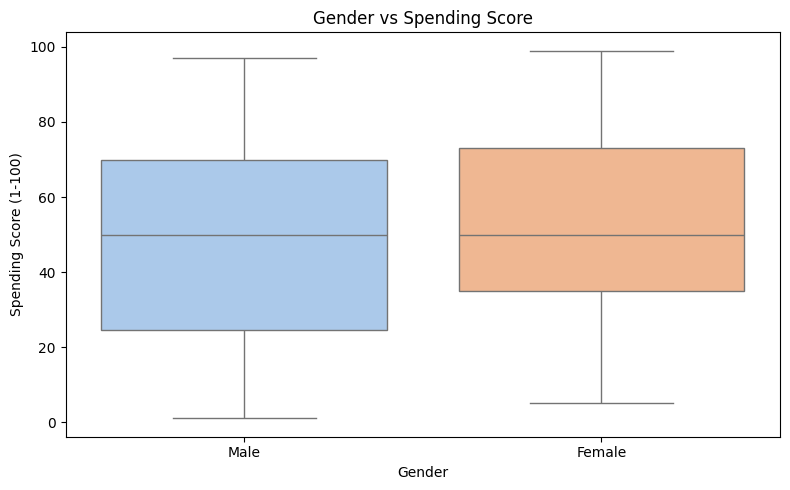

Female customers tend to have slightly higher spending scores


In [10]:
# ================================================
# Visualization 5: Gender vs Spending Score
# Does gender affect spending behavior?
# ================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Gender',                     # Gender groups
    y='SpendingScore',              # Spending score
    hue='Gender',                   # Color by gender
    palette='pastel',               # Color palette
    legend=False                    # Hide legend
)

plt.title('Gender vs Spending Score')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.savefig('gender_spending.png')
plt.show()

print("Female customers tend to have slightly higher spending scores")

## 5. Model Training and Testing

We use the Elbow Method to find the optimal number of clusters
and then apply K-Means Clustering to segment the customers into
distinct groups based on their income and spending behavior.

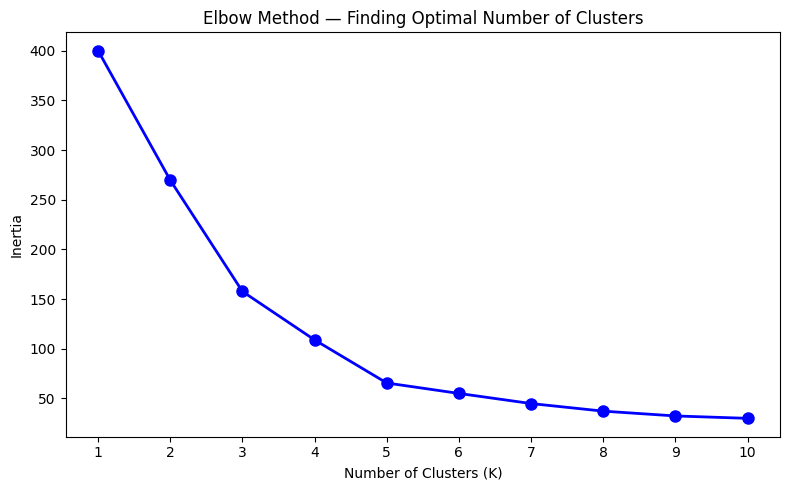

Look for the elbow point where the curve bends!
The optimal K is usually 5 for this dataset


In [11]:
# ================================================
# Finding Optimal Number of Clusters
# Using the Elbow Method
# We try K from 1 to 10 and look for the elbow
# point where adding more clusters stops helping
# ================================================

inertia = []                        # Store inertia for each K
K_range = range(1, 11)              # Try K from 1 to 10

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,               # Number of clusters
        random_state=42,            # For reproducibility
        n_init=10                   # Number of initializations
    )
    kmeans.fit(X_scaled)            # Fit to scaled data
    inertia.append(kmeans.inertia_) # Store inertia value

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()

print("Look for the elbow point where the curve bends!")
print("The optimal K is usually 5 for this dataset")

In [12]:
# ================================================
# Applying K-Means Clustering with K=5
# 5 clusters is the optimal number based on
# the Elbow Method for this dataset
# ================================================

kmeans = KMeans(
    n_clusters=5,                   # 5 customer segments
    random_state=42,                # For reproducibility
    n_init=10                       # Number of initializations
)

# Fit and predict clusters
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Show cluster distribution
print("Customer Distribution Across Clusters:")
print(df['Cluster'].value_counts().sort_index())
print("\nCluster Centers (scaled):")
print(kmeans.cluster_centers_)

Customer Distribution Across Clusters:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Centers (scaled):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


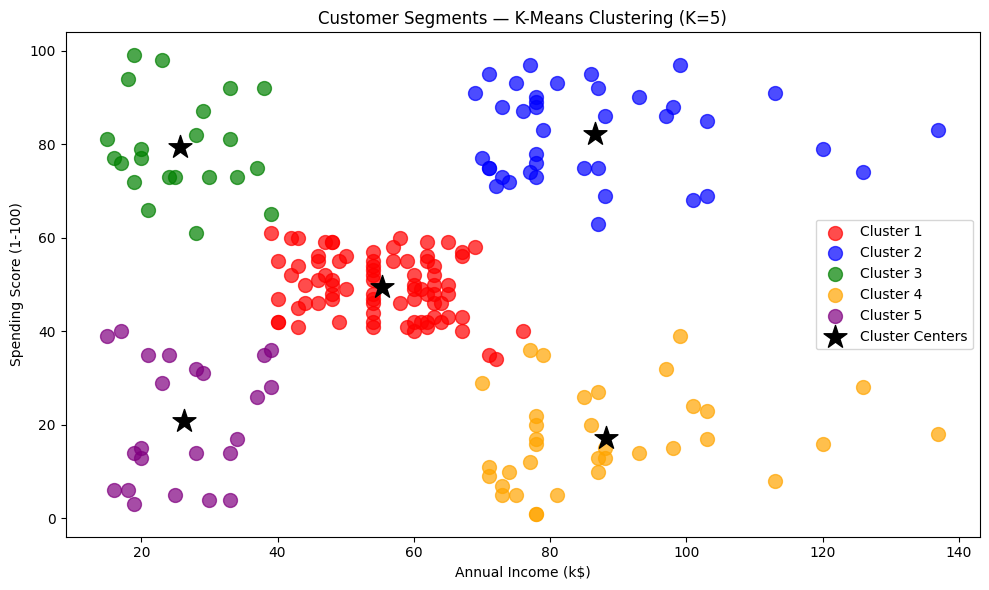

5 distinct customer segments identified!


In [13]:
# ================================================
# Visualization 6: Customer Segments (Clusters)
# Showing the 5 customer segments on a scatter plot
# Each color represents a different segment
# ================================================

plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3',
          'Cluster 4', 'Cluster 5']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['AnnualIncome'],
        cluster_data['SpendingScore'],
        c=colors[i],
        label=labels[i],
        s=100,
        alpha=0.7
    )

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    marker='*',
    s=300,
    label='Cluster Centers'
)

plt.title('Customer Segments — K-Means Clustering (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('customer_clusters.png')
plt.show()

print("5 distinct customer segments identified!")

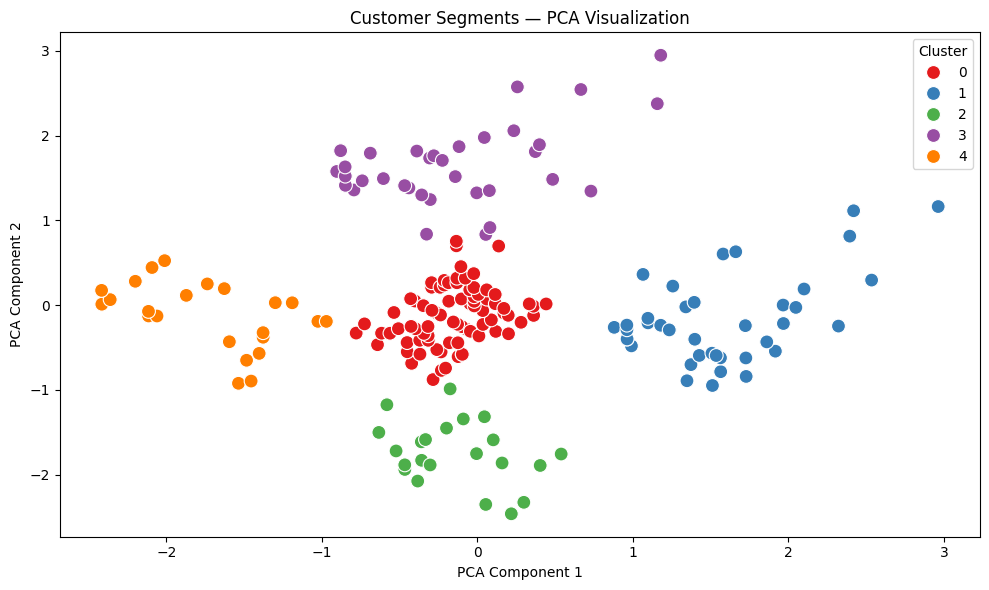

PCA visualization complete!
Variance explained: 100.00%


In [14]:
# ================================================
# PCA Visualization
# Reducing dimensions to visualize clusters
# PCA = Principal Component Analysis
# ================================================

# Import PCA here directly
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA Component 1', 'PCA Component 2']
)
pca_df['Cluster'] = df['Cluster']

# Plot PCA visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PCA Component 1',
    y='PCA Component 2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segments — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('pca_clusters.png')
plt.show()

print("PCA visualization complete!")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

In [15]:
# ================================================
# Analyzing Each Customer Segment
# Understanding characteristics of each cluster
# ================================================

print("CUSTOMER SEGMENT ANALYSIS")
print("="*50)

# Check actual column names first
print("Columns in dataset:", df.columns.tolist())

cluster_summary = df.groupby('Cluster').agg({
    'AnnualIncome': 'mean',
    'SpendingScore': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
}).round(2)

cluster_summary.columns = ['Avg Income (k$)',
                            'Avg Spending Score',
                            'Avg Age',
                            'Customer Count']

print("\nCluster Summary:")
print(cluster_summary)

CUSTOMER SEGMENT ANALYSIS
Columns in dataset: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore', 'Cluster']

Cluster Summary:
         Avg Income (k$)  Avg Spending Score  Avg Age  Customer Count
Cluster                                                              
0                  55.30               49.52    42.72              81
1                  86.54               82.13    32.69              39
2                  25.73               79.36    25.27              22
3                  88.20               17.11    41.11              35
4                  26.30               20.91    45.22              23


## 6. Evaluation Metrics

K-Means clustering does not use traditional metrics like accuracy
since there is no target variable. Instead we evaluate the quality
of clusters using Inertia and the Elbow Method.

Inertia measures how tightly packed the clusters are. Lower inertia
means better defined clusters. The Elbow Method helps us find the
optimal number of clusters by looking for the point where adding
more clusters gives diminishing returns.

We also use PCA visualization to confirm that the clusters are
well separated from each other in the feature space.

In [16]:
# ================================================
# Cluster Quality Evaluation
# Measuring how good our clusters are
# ================================================

from sklearn.metrics import silhouette_score

# Calculate silhouette score
# Score ranges from -1 to 1
# Higher score = better defined clusters
sil_score = silhouette_score(X_scaled, df['Cluster'])

print("CLUSTERING EVALUATION METRICS")
print("="*40)
print(f"Number of Clusters:  5")
print(f"Final Inertia:       {kmeans.inertia_:.2f}")
print(f"Silhouette Score:    {sil_score:.3f}")
print(f"\nSilhouette Score Interpretation:")
print(f"0.7 - 1.0  = Strong clusters")
print(f"0.5 - 0.7  = Reasonable clusters")
print(f"0.25 - 0.5 = Weak clusters")
print(f"\nOur Score: {sil_score:.3f} ✅")

CLUSTERING EVALUATION METRICS
Number of Clusters:  5
Final Inertia:       65.57
Silhouette Score:    0.555

Silhouette Score Interpretation:
0.7 - 1.0  = Strong clusters
0.5 - 0.7  = Reasonable clusters
0.25 - 0.5 = Weak clusters

Our Score: 0.555 ✅


## 7. Conclusion and Key Insights

K-Means Clustering successfully identified 5 distinct customer
segments in the mall dataset based on annual income and spending score.

Segment 1 — High Income Low Spenders (Careful Spenders):
These customers earn a lot but spend very little. They are likely
saving money or are not impressed by current offerings. The bank
should offer them premium products and exclusive loyalty programs
to encourage higher spending.

Segment 2 — Low Income Low Spenders (Sensible Customers):
These customers have both low income and low spending. They are
budget conscious and careful with money. Marketing should focus
on discounts, offers, and value for money deals to attract them.

Segment 3 — Medium Income Medium Spenders (Standard Customers):
These are the average customers who form the bulk of the customer
base. They respond well to standard marketing campaigns and seasonal
promotions. Loyalty cards and regular discounts work best for them.

Segment 4 — High Income High Spenders (Target Customers):
These are the most valuable customers. They earn well and spend
freely. The mall should focus maximum marketing efforts on retaining
these customers through VIP programs and personalized experiences.

Segment 5 — Low Income High Spenders (Careless Spenders):
These customers spend more than their income suggests. They may
be using credit or are highly impulsive buyers. Targeted promotions
and installment payment options would work well for this group.

The PCA visualization confirmed that the 5 clusters are well
separated from each other showing that K-Means successfully
identified meaningful and distinct customer segments.

Business Recommendation: The mall should prioritize Segment 4
(High Income High Spenders) for premium marketing campaigns while
using discount strategies for Segment 2 and Segment 5 customers.
Loyalty programs should target Segment 3 to move them toward
higher spending behavior over time.